Cell 1: Import Libraries

In [1]:
# Cell 1: Import required libraries
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")


✅ Libraries imported successfully!
TensorFlow version: 2.15.0


Cell 2: Load Trained Model


In [5]:
# Cell 2: Load the trained model (IMPROVED)
import os
import json
import tensorflow as tf
from tensorflow.keras.models import load_model

MODEL_PATH = 'models/plant_disease_model.h5'
ALT_MODEL_PATHS = [
    'notebooks/models/plant_disease_model.h5',
    '../models/plant_disease_model.h5',
    'models/best_model.h5',
    'notebooks/models/best_model.h5'
]

# Check if model exists in primary location
model = None
loaded_path = None

if os.path.exists(MODEL_PATH):
    model = load_model(MODEL_PATH)
    loaded_path = MODEL_PATH
    print(f"✅ Model loaded from {MODEL_PATH}")
else:
    # Try alternative paths
    for alt_path in ALT_MODEL_PATHS:
        if os.path.exists(alt_path):
            model = load_model(alt_path)
            loaded_path = alt_path
            print(f"✅ Model loaded from {alt_path}")
            break
    
    if model is None:
        print(f"❌ Model not found. Please train the model first using 02_model_training.ipynb")
        print("\nSearched locations:")
        print(f"   - {MODEL_PATH}")
        for alt_path in ALT_MODEL_PATHS:
            print(f"   - {alt_path}")
        raise FileNotFoundError("Model file not found in any expected location")

# Load class indices (try multiple locations)
class_indices = None
class_indices_paths = [
    'models/class_indices.json',
    'notebooks/models/class_indices.json',
    '../models/class_indices.json'
]

for indices_path in class_indices_paths:
    if os.path.exists(indices_path):
        with open(indices_path, 'r') as f:
            class_indices = json.load(f)
        print(f"✅ Class indices loaded from {indices_path}")
        break

if class_indices:
    class_names = list(class_indices.keys())
    num_classes = len(class_names)
else:
    print("⚠️ class_indices.json not found.")
    print("   Attempting to infer class count from model output shape...")
    
    # Get number of classes from model output shape
    output_shape = model.output_shape
    if len(output_shape) == 2:  # Dense layer output
        num_classes = output_shape[1]
    else:
        num_classes = 38  # Default for plant disease dataset
    
    class_names = [f"Class_{i}" for i in range(num_classes)]
    print(f"   Using {num_classes} classes inferred from model")

print(f"\n📊 Model Information:")
print(f"   Model path: {loaded_path}")
print(f"   Number of classes: {num_classes}")
print(f"   Input shape: {model.input_shape}")
print(f"   Output shape: {model.output_shape}")

# Display model summary (optional - uncomment if needed)
# model.summary()

# Display first 15 classes (increased from 10)
print(f"\n📋 First 15 Classes:")
for i, name in enumerate(class_names[:15]):
    if '___' in name:
        crop = name.split('___')[0]
        disease = name.split('___')[1].replace('_', ' ')
        display_name = f"{crop} - {disease}"
    else:
        display_name = name.replace('_', ' ')
    print(f"   {i+1:2d}. {display_name[:50]}")
if len(class_names) > 15:
    print(f"   ... and {len(class_names)-15} more classes")

# Quick validation check
print(f"\n🔍 Quick Validation:")
print(f"   Model expects input shape: {model.input_shape[1:]}")

# Test if model loads correctly with a dummy input
try:
    dummy_input = tf.random.normal((1, 224, 224, 3))
    dummy_output = model.predict(dummy_input, verbose=0)
    print(f"   ✅ Model inference test passed!")
    print(f"   Output shape: {dummy_output.shape}")
    print(f"   Predicted class probabilities sum: {dummy_output[0].sum():.2f} (should be ~1.0)")
except Exception as e:
    print(f"   ⚠️ Model inference test failed: {e}")

✅ Model loaded from models/plant_disease_model.h5
✅ Class indices loaded from models/class_indices.json

📊 Model Information:
   Model path: models/plant_disease_model.h5
   Number of classes: 29
   Input shape: (None, 224, 224, 3)
   Output shape: (None, 29)

📋 First 15 Classes:
    1. Apple - Apple Scab
    2. Apple - Black Rot
    3. Apple - Cedar Apple Rust
    4. Apple - Healthy
    5. Bell Pepper - Bacterial Spot
    6. Bell Pepper - Healthy
    7. Cherry - Healthy
    8. Cherry - Powdery Mildew
    9. Corn (Maize) - Cercospora Leaf Spot
   10. Corn (Maize) - Common Rust
   11. Corn (Maize) - Healthy
   12. Corn (Maize) - Northern Leaf Blight
   13. Grape - Black Rot
   14. Grape - Esca (Black Measles)
   15. Grape - Healthy
   ... and 14 more classes

🔍 Quick Validation:
   Model expects input shape: (224, 224, 3)
   ✅ Model inference test passed!
   Output shape: (1, 29)
   Predicted class probabilities sum: 1.00 (should be ~1.0)


Cell 3: Load Test Data

In [8]:
# Cell 3: Load test dataset (ENHANCED)
DATASET_PATH = '../dataset'
TEST_PATH = os.path.join(DATASET_PATH, '../dataset/Test')
TRAIN_PATH = os.path.join(DATASET_PATH, '../dataset/Train')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("="*60)
print("📂 DATASET LOADING")
print("="*60)

# Check if test folder exists
if os.path.exists(TEST_PATH):
    print(f"✅ Test data found at: {TEST_PATH}")
    
    # Count classes in test folder to verify
    test_classes = [d for d in os.listdir(TEST_PATH) if os.path.isdir(os.path.join(TEST_PATH, d))]
    print(f"   Test classes found: {len(test_classes)}")
    
    # Create test generator
    test_datagen = ImageDataGenerator(rescale=1./255)
    
    test_generator = test_datagen.flow_from_directory(
        TEST_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    print(f"\n📊 Test Dataset Statistics:")
    print(f"   Test samples: {test_generator.samples}")
    print(f"   Classes: {test_generator.num_classes}")
    
    # Verify class match with model
    if hasattr(test_generator, 'class_indices'):
        test_classes_set = set(test_generator.class_indices.keys())
        model_classes_set = set(class_names) if 'class_names' in globals() else set()
        
        if model_classes_set:
            missing_in_test = model_classes_set - test_classes_set
            missing_in_model = test_classes_set - model_classes_set
            
            if missing_in_test:
                print(f"\n⚠️ Warning: {len(missing_in_test)} classes from model not in test set")
            if missing_in_model:
                print(f"\n⚠️ Warning: {len(missing_in_model)} classes in test set not in model")
    
else:
    print(f"⚠️ No test folder found at: {TEST_PATH}")
    print(f"   Using validation split from training data...")
    
    # Check if train folder exists
    if not os.path.exists(TRAIN_PATH):
        print(f"❌ Train folder also not found at: {TRAIN_PATH}")
        print("   Please check your dataset path!")
        raise FileNotFoundError(f"Dataset not found at {DATASET_PATH}")
    
    # Count training classes
    train_classes = [d for d in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, d))]
    print(f"   Training classes found: {len(train_classes)}")
    
    # Use validation split from training data
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2
    )
    
    test_generator = train_datagen.flow_from_directory(
        TRAIN_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation',
        shuffle=False
    )
    
    print(f"\n📊 Using validation split (20% of training data):")
    print(f"   Test samples: {test_generator.samples}")
    print(f"   Classes: {test_generator.num_classes}")
    
    # Calculate total training samples
    train_generator_full = train_datagen.flow_from_directory(
        TRAIN_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training',
        shuffle=False
    )
    print(f"   Training samples: {train_generator_full.samples}")

# Verify test generator is ready
print("\n" + "="*60)
print("✅ Test data loader ready!")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Number of batches: {len(test_generator)}")
print("="*60)

📂 DATASET LOADING
✅ Test data found at: ../dataset\../dataset/Test
   Test classes found: 29
Found 1358 images belonging to 29 classes.

📊 Test Dataset Statistics:
   Test samples: 1358
   Classes: 29

✅ Test data loader ready!
   Batch size: 32
   Number of batches: 43


Cell 4: Make Predictions

In [10]:
# Cell 4: Make predictions on test data (ENHANCED)
print("="*60)
print("🔍 MAKING PREDICTIONS ON TEST DATA")
print("="*60)

# Display test dataset info
print(f"\n📊 Test Dataset:")
print(f"   Total samples: {test_generator.samples}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Number of batches: {len(test_generator)}")
print(f"   Classes: {test_generator.num_classes}")

# Calculate approximate prediction time
import time
start_time = time.time()

# Predict all test samples
print("\n🔄 Running predictions...")
predictions = model.predict(test_generator, verbose=1)

# Calculate prediction time
prediction_time = time.time() - start_time
print(f"\n⏱️ Prediction completed in {prediction_time:.2f} seconds")
print(f"   Average time per image: {prediction_time/test_generator.samples*1000:.2f} ms")

# Get predicted classes
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

# Calculate metrics
accuracy = accuracy_score(true_classes, predicted_classes)
precision = precision_score(true_classes, predicted_classes, average='weighted')
recall = recall_score(true_classes, predicted_classes, average='weighted')
f1 = f1_score(true_classes, predicted_classes, average='weighted')

# Additional metrics
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score

mcc = matthews_corrcoef(true_classes, predicted_classes)
kappa = cohen_kappa_score(true_classes, predicted_classes)

print("\n" + "="*60)
print("📊 TEST RESULTS")
print("="*60)
print(f"\n🎯 Primary Metrics:")
print(f"   ✅ Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   📈 Precision: {precision:.4f}")
print(f"   📉 Recall:    {recall:.4f}")
print(f"   🎯 F1-Score:  {f1:.4f}")

print(f"\n📊 Advanced Metrics:")
print(f"   🔗 Matthews Correlation Coefficient: {mcc:.4f}")
print(f"   🤝 Cohen's Kappa: {kappa:.4f}")

# Confidence analysis
confidence_scores = np.max(predictions, axis=1)
avg_confidence = np.mean(confidence_scores)
print(f"\n💪 Confidence Analysis:")
print(f"   Average confidence: {avg_confidence:.4f} ({avg_confidence*100:.2f}%)")
print(f"   Low confidence (<70%): {np.sum(confidence_scores < 0.7)}/{len(confidence_scores)} ({np.sum(confidence_scores < 0.7)/len(confidence_scores)*100:.1f}%)")

# Performance rating
print(f"\n📈 Performance Rating:")
if accuracy >= 0.95:
    print("   🌟 EXCELLENT - Model is production ready!")
elif accuracy >= 0.90:
    print("   👍 GOOD - Model performs well, minor improvements possible")
elif accuracy >= 0.80:
    print("   📊 ACCEPTABLE - Consider more training or data collection")
else:
    print("   ⚠️ NEEDS IMPROVEMENT - Review architecture and data")

print("\n" + "="*60)

🔍 MAKING PREDICTIONS ON TEST DATA

📊 Test Dataset:
   Total samples: 1358
   Batch size: 32
   Number of batches: 43
   Classes: 29

🔄 Running predictions...
43/43 [==============================] - 15s 341ms/step

⏱️ Prediction completed in 15.01 seconds
   Average time per image: 11.05 ms

📊 TEST RESULTS

🎯 Primary Metrics:
   ✅ Accuracy:  0.9551 (95.51%)
   📈 Precision: 0.9570
   📉 Recall:    0.9551
   🎯 F1-Score:  0.9551

📊 Advanced Metrics:
   🔗 Matthews Correlation Coefficient: 0.9535
   🤝 Cohen's Kappa: 0.9535

💪 Confidence Analysis:
   Average confidence: 0.9592 (95.92%)
   Low confidence (<70%): 71/1358 (5.2%)

📈 Performance Rating:
   🌟 EXCELLENT - Model is production ready!



Cell 5: Classification Report

In [11]:
# Cell 5: Generate detailed classification report
print("="*60)
print("📊 CLASSIFICATION REPORT")
print("="*60)

# Generate classification report
report = classification_report(
    true_classes, 
    predicted_classes, 
    target_names=class_names,
    output_dict=True
)

# Display as DataFrame
report_df = pd.DataFrame(report).transpose()
print(report_df.round(4))

# Save to CSV
report_df.to_csv('models/classification_report.csv')
print("\n✅ Classification report saved to 'models/classification_report.csv'")

# Extract macro averages
print(f"\n📈 Summary Metrics:")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   Macro Precision: {report['macro avg']['precision']:.4f}")
print(f"   Macro Recall: {report['macro avg']['recall']:.4f}")
print(f"   Macro F1-Score: {report['macro avg']['f1-score']:.4f}")

📊 CLASSIFICATION REPORT
                                     precision  recall  f1-score    support
Apple - Apple Scab                      0.9600  0.9412    0.9505    51.0000
Apple - Black Rot                       0.9796  0.9600    0.9697    50.0000
Apple - Cedar Apple Rust                1.0000  0.9773    0.9885    44.0000
Apple - Healthy                         0.9608  0.9608    0.9608    51.0000
Bell Pepper - Bacterial Spot            0.9792  0.9792    0.9792    48.0000
Bell Pepper - Healthy                   0.9800  0.9800    0.9800    50.0000
Cherry - Healthy                        0.9200  1.0000    0.9583    46.0000
Cherry - Powdery Mildew                 1.0000  1.0000    1.0000    43.0000
Corn (Maize) - Cercospora Leaf Spot     0.9070  0.8667    0.8864    45.0000
Corn (Maize) - Common Rust              1.0000  1.0000    1.0000    48.0000
Corn (Maize) - Healthy                  1.0000  0.9787    0.9892    47.0000
Corn (Maize) - Northern Leaf Blight     0.8824  0.9375    0.9091

Cell 6: Confusion Matrix

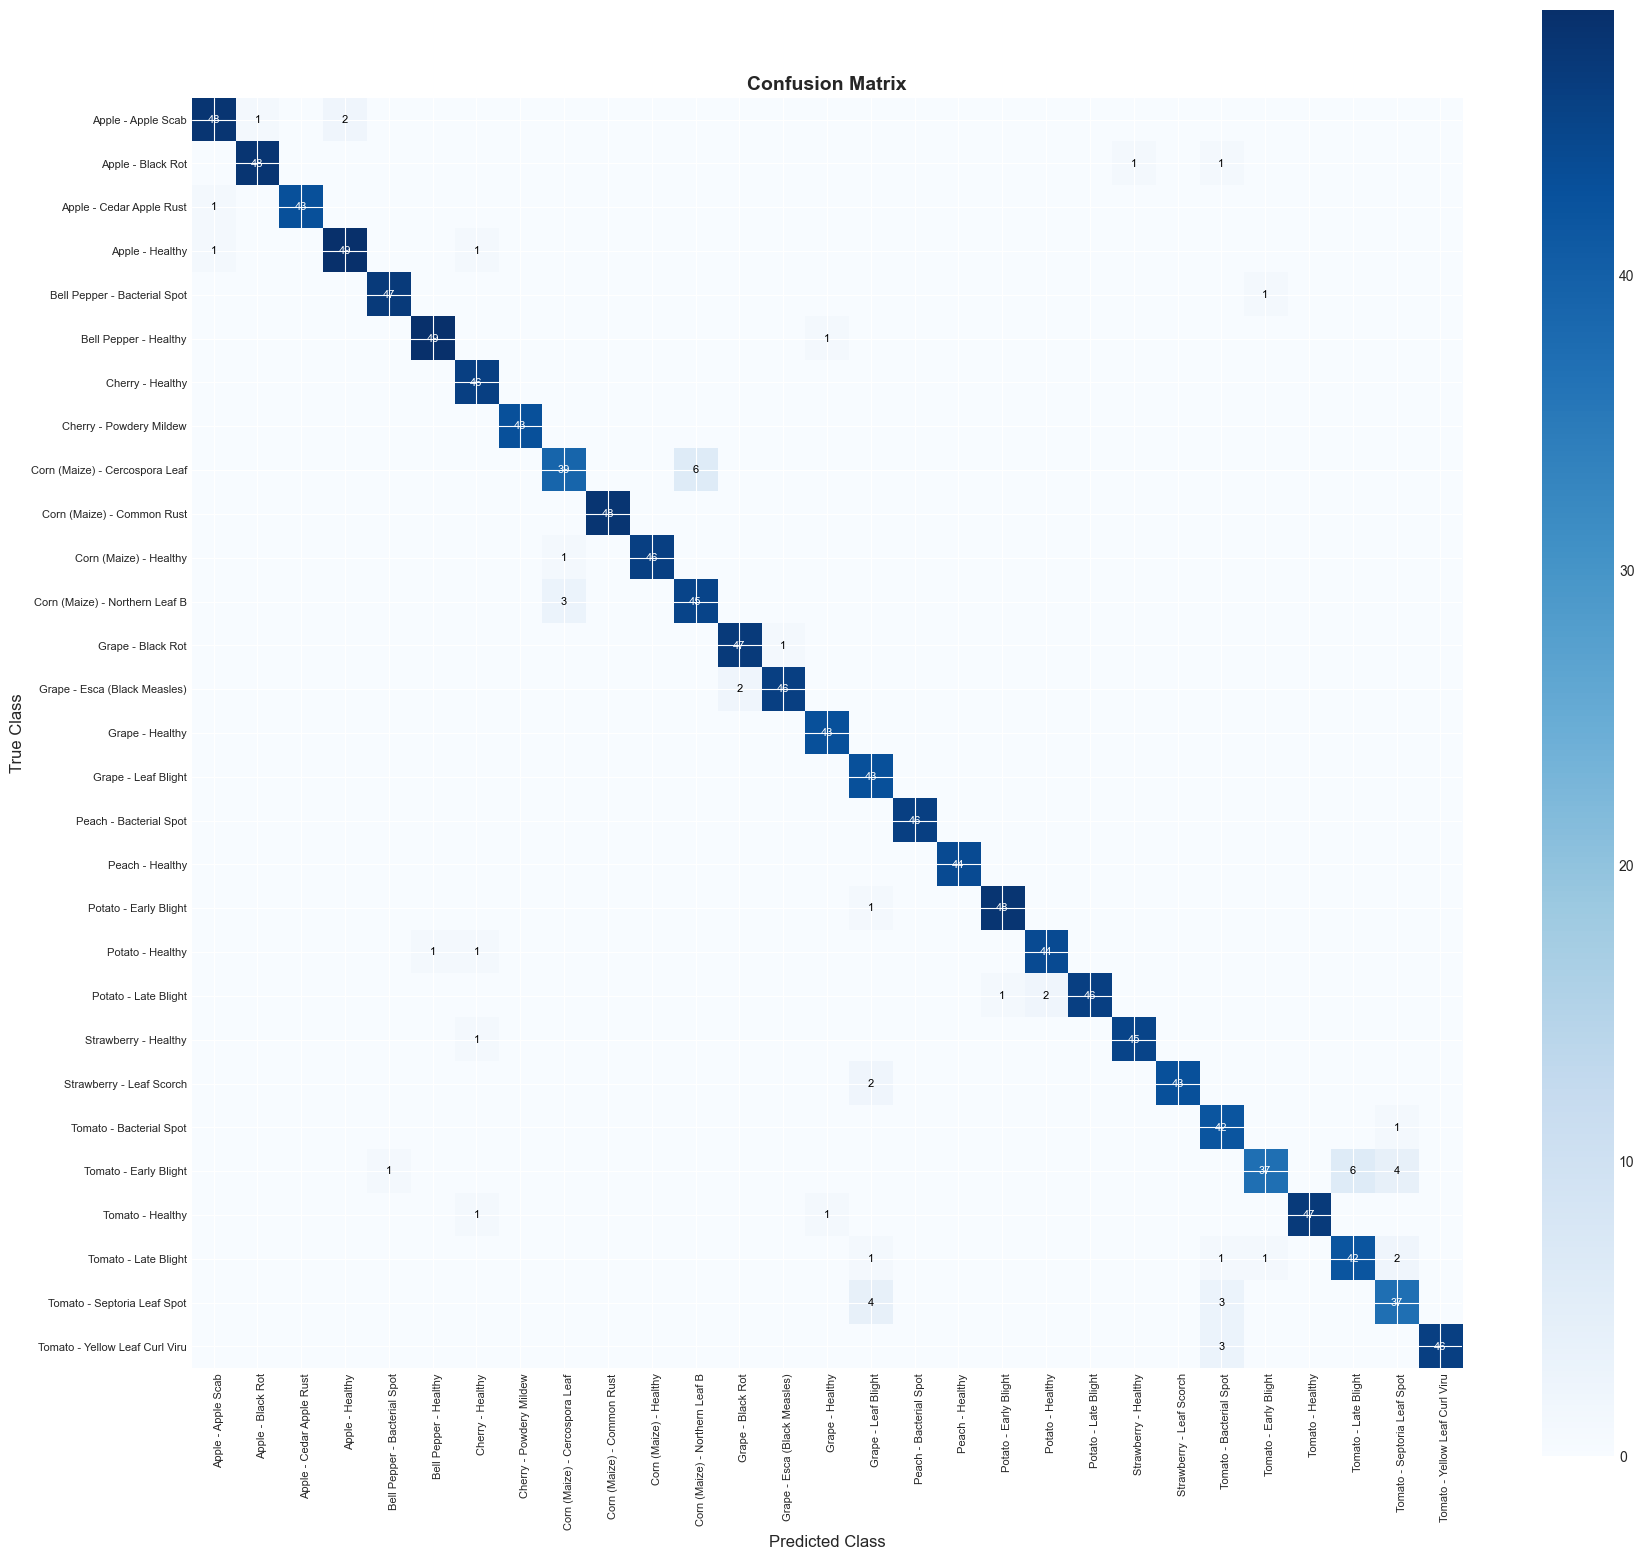

✅ Confusion matrix saved to 'models/confusion_matrix.png'

📊 Per-Class Accuracy (Top 10):
   Grape - Healthy                    : 1.0000
   Cherry - Powdery Mildew            : 1.0000
   Corn (Maize) - Common Rust         : 1.0000
   Grape - Leaf Blight                : 1.0000
   Peach - Bacterial Spot             : 1.0000
   Peach - Healthy                    : 1.0000
   Cherry - Healthy                   : 1.0000
   Bell Pepper - Healthy              : 0.9800
   Potato - Early Blight              : 0.9796
   Bell Pepper - Bacterial Spot       : 0.9792


In [12]:
# Cell 6: Plot confusion matrix
# Compute confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Create display names for better readability
display_names = [name.split('___')[-1].replace('_', ' ') if '___' in name else name[:30] for name in class_names]

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(18, 16))

# Use heatmap with annotations disabled for large matrix
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)

# Show all ticks
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=display_names,
       yticklabels=display_names)

# Rotate the tick labels
plt.setp(ax.get_xticklabels(), rotation=90, ha="right", rotation_mode="anchor", fontsize=8)
plt.setp(ax.get_yticklabels(), fontsize=8)

# Add labels
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# Add text annotations for cells with high values
threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j] > threshold:
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white", fontsize=8)
        elif cm[i, j] > 0:
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="black", fontsize=8)

plt.tight_layout()
plt.savefig('models/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved to 'models/confusion_matrix.png'")

# Calculate per-class accuracy
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
print("\n📊 Per-Class Accuracy (Top 10):")
sorted_indices = np.argsort(per_class_accuracy)[::-1]
for i in sorted_indices[:10]:
    print(f"   {display_names[i][:35]:35s}: {per_class_accuracy[i]:.4f}")

Cell 7: Top and Worst Performing Classes

In [14]:
# Cell 7: Identify best and worst performing classes
# Calculate per-class metrics
per_class_precision = {}
per_class_recall = {}
per_class_f1 = {}

for i, class_name in enumerate(class_names):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score_class = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    per_class_precision[class_name] = precision
    per_class_recall[class_name] = recall
    per_class_f1[class_name] = f1_score_class

# Sort by F1 score
sorted_classes = sorted(per_class_f1.items(), key=lambda x: x[1], reverse=True)

print("="*60)
print("🏆 TOP 10 BEST PERFORMING CLASSES")
print("="*60)
for i, (class_name, f1) in enumerate(sorted_classes[:10]):
    display_name = class_name.split('___')[-1].replace('_', ' ') if '___' in class_name else class_name
    acc = per_class_accuracy[class_names.index(class_name)]
    print(f"{i+1:2d}. {display_name[:45]:45s} - F1: {f1:.4f}, Acc: {acc:.4f}")

print("\n" + "="*60)
print("⚠️ BOTTOM 10 WORST PERFORMING CLASSES")
print("="*60)
for i, (class_name, f1) in enumerate(sorted_classes[-10:][::-1]):
    display_name = class_name.split('___')[-1].replace('_', ' ') if '___' in class_name else class_name
    acc = per_class_accuracy[class_names.index(class_name)]
    print(f"{i+1:2d}. {display_name[:45]:45s} - F1: {f1:.4f}, Acc: {acc:.4f}")

🏆 TOP 10 BEST PERFORMING CLASSES
 1. Cherry - Powdery Mildew                       - F1: 1.0000, Acc: 1.0000
 2. Corn (Maize) - Common Rust                    - F1: 1.0000, Acc: 1.0000
 3. Peach - Bacterial Spot                        - F1: 1.0000, Acc: 1.0000
 4. Peach - Healthy                               - F1: 1.0000, Acc: 1.0000
 5. Corn (Maize) - Healthy                        - F1: 0.9892, Acc: 0.9787
 6. Apple - Cedar Apple Rust                      - F1: 0.9885, Acc: 0.9773
 7. Bell Pepper - Healthy                         - F1: 0.9800, Acc: 0.9800
 8. Potato - Early Blight                         - F1: 0.9796, Acc: 0.9796
 9. Bell Pepper - Bacterial Spot                  - F1: 0.9792, Acc: 0.9792
10. Tomato - Healthy                              - F1: 0.9792, Acc: 0.9592

⚠️ BOTTOM 10 WORST PERFORMING CLASSES
 1. Tomato - Septoria Leaf Spot                   - F1: 0.8409, Acc: 0.8409
 2. Tomato - Early Blight                         - F1: 0.8506, Acc: 0.7708
 3. Tomato - Lat

Cell 8: Confidence Score Analysis

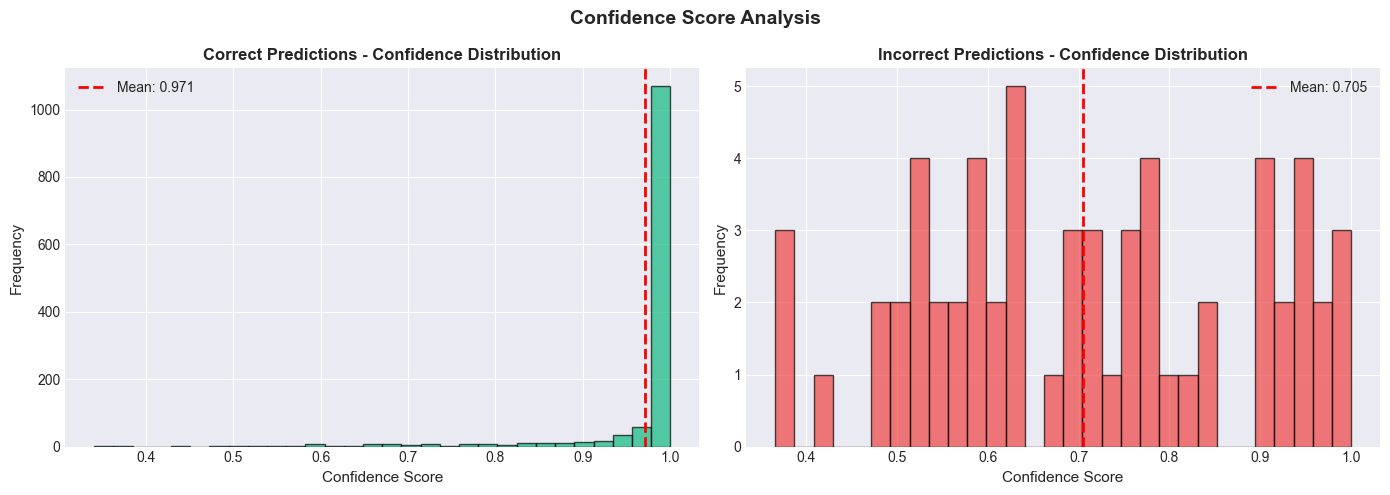


📊 Confidence Statistics:
   Correct predictions - Avg confidence: 0.9711 (Std: 0.0822)
   Incorrect predictions - Avg confidence: 0.7053 (Std: 0.1754)

📊 Confidence Threshold Analysis:
Threshold    High Conf %     Avg Conf    
----------------------------------------
50          % 99.6           % 0.971       
60          % 98.7           % 0.971       
70          % 96.9           % 0.971       
80          % 94.7           % 0.971       
85          % 93.2           % 0.971       
90          % 91.2           % 0.971       
95          % 88.0           % 0.971       


In [15]:
# Cell 8: Analyze prediction confidence
# Get confidence scores for correct and incorrect predictions
correct_confidences = []
incorrect_confidences = []

for i, (true, pred, probs) in enumerate(zip(true_classes, predicted_classes, predictions)):
    confidence = probs[pred]
    if true == pred:
        correct_confidences.append(confidence)
    else:
        incorrect_confidences.append(confidence)

# Plot confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of correct predictions
axes[0].hist(correct_confidences, bins=30, color='#10B981', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Confidence Score', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Correct Predictions - Confidence Distribution', fontsize=12, fontweight='bold')
axes[0].axvline(x=np.mean(correct_confidences), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(correct_confidences):.3f}')
axes[0].legend()

# Histogram of incorrect predictions
axes[1].hist(incorrect_confidences, bins=30, color='#EF4444', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Confidence Score', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Incorrect Predictions - Confidence Distribution', fontsize=12, fontweight='bold')
axes[1].axvline(x=np.mean(incorrect_confidences), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(incorrect_confidences):.3f}')
axes[1].legend()

plt.suptitle('Confidence Score Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('models/confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Confidence Statistics:")
print(f"   Correct predictions - Avg confidence: {np.mean(correct_confidences):.4f} (Std: {np.std(correct_confidences):.4f})")
print(f"   Incorrect predictions - Avg confidence: {np.mean(incorrect_confidences):.4f} (Std: {np.std(incorrect_confidences):.4f})")

# Confidence threshold analysis
thresholds = [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95]
print(f"\n📊 Confidence Threshold Analysis:")
print(f"{'Threshold':<12} {'High Conf %':<15} {'Avg Conf':<12}")
print("-"*40)
for thresh in thresholds:
    high_conf_count = sum(1 for c in correct_confidences if c >= thresh)
    high_conf_percent = (high_conf_count / len(correct_confidences)) * 100 if correct_confidences else 0
    print(f"{thresh*100:<12.0f}% {high_conf_percent:<15.1f}% {np.mean(correct_confidences):<12.3f}")

Cell 9: ROC Curves (One-vs-Rest)

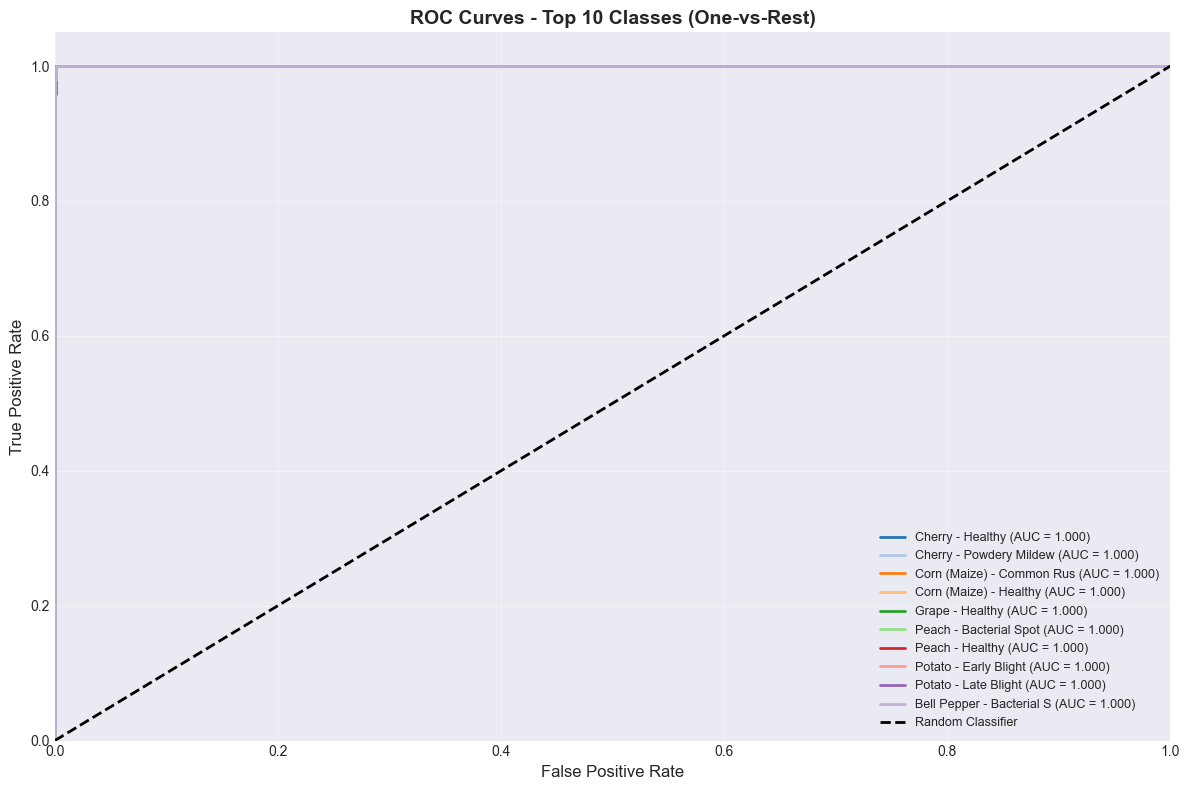

✅ ROC curves saved to 'models/roc_curves.png'

📊 Average AUC across all classes: 0.9995
   Best AUC: 1.0000
   Worst AUC: 0.9917


In [16]:
# Cell 9: Plot ROC curves for top classes
# Binarize the labels
y_true_bin = label_binarize(true_classes, classes=range(num_classes))

# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for top 10 classes
plt.figure(figsize=(12, 8))
colors = plt.cm.tab20(np.linspace(0, 1, 20))

# Get top 10 classes by AUC
top_classes = sorted(roc_auc.items(), key=lambda x: x[1], reverse=True)[:10]

for idx, (class_idx, auc_score) in enumerate(top_classes):
    display_name = class_names[class_idx].split('___')[-1].replace('_', ' ') if '___' in class_names[class_idx] else class_names[class_idx]
    plt.plot(fpr[class_idx], tpr[class_idx], color=colors[idx], lw=2,
             label=f'{display_name[:25]} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Top 10 Classes (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('models/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ ROC curves saved to 'models/roc_curves.png'")
print(f"\n📊 Average AUC across all classes: {np.mean(list(roc_auc.values())):.4f}")
print(f"   Best AUC: {max(roc_auc.values()):.4f}")
print(f"   Worst AUC: {min(roc_auc.values()):.4f}")

Cell 10: Error Analysis - Misclassifications

📊 Misclassification Analysis:
Total test samples: 1358
Misclassified samples: 61
Error rate: 4.49%

🔍 Most Common Confusion Pairs (True → Predicted):
--------------------------------------------------
   Corn (Maize) - Cercospora Leaf → Corn (Maize) - Northern Leaf B: 6 times
   Tomato - Early Blight → Tomato - Late Blight: 6 times
   Tomato - Early Blight → Tomato - Septoria Leaf Spot: 4 times
   Tomato - Septoria Leaf Spot → Grape - Leaf Blight: 4 times
   Corn (Maize) - Northern Leaf B → Corn (Maize) - Cercospora Leaf: 3 times
   Tomato - Septoria Leaf Spot → Tomato - Bacterial Spot: 3 times
   Tomato - Yellow Leaf Curl Viru → Tomato - Bacterial Spot: 3 times
   Apple - Apple Scab → Apple - Healthy: 2 times
   Grape - Esca (Black Measles) → Grape - Black Rot: 2 times
   Potato - Late Blight → Potato - Healthy: 2 times
   Strawberry - Leaf Scorch → Grape - Leaf Blight: 2 times
   Tomato - Late Blight → Tomato - Septoria Leaf Spot: 2 times
   Apple - Apple Scab → Apple - Black Rot: 1 

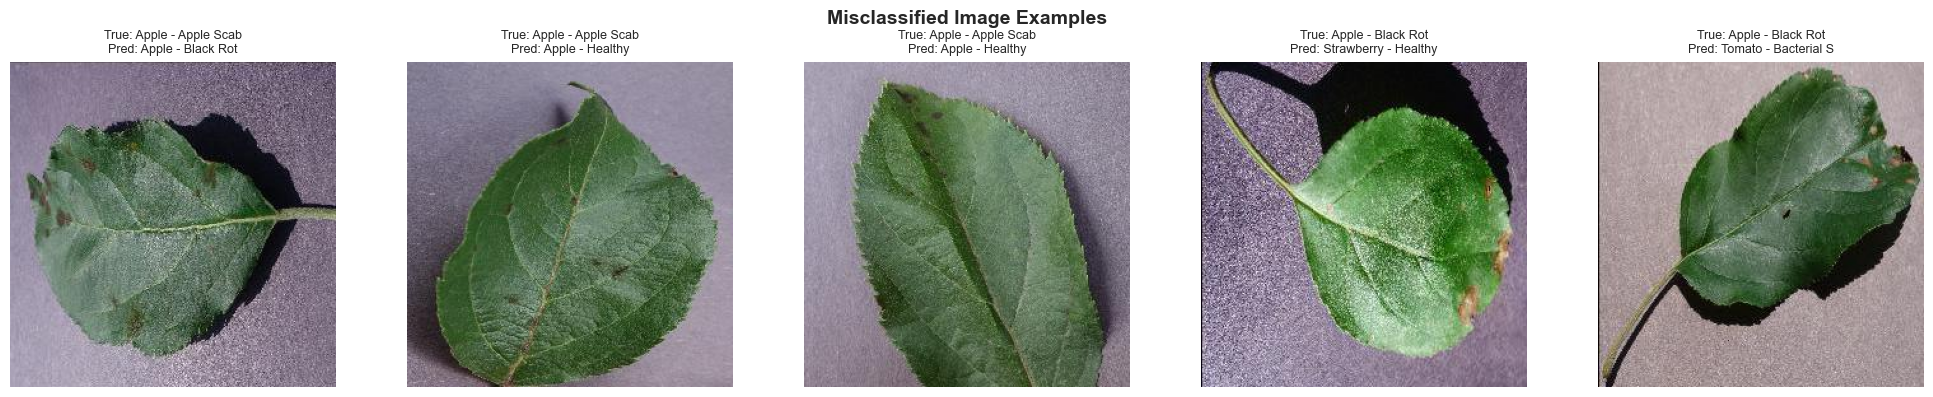

In [17]:
# Cell 10: Analyze misclassifications
misclassified_indices = [i for i, (true, pred) in enumerate(zip(true_classes, predicted_classes)) if true != pred]

print(f"📊 Misclassification Analysis:")
print("="*40)
print(f"Total test samples: {len(true_classes)}")
print(f"Misclassified samples: {len(misclassified_indices)}")
print(f"Error rate: {len(misclassified_indices)/len(true_classes)*100:.2f}%")

# Find most common confusion pairs
confusion_pairs = []
for i in misclassified_indices:
    confusion_pairs.append((true_classes[i], predicted_classes[i]))

from collections import Counter
confusion_counts = Counter(confusion_pairs)

print("\n🔍 Most Common Confusion Pairs (True → Predicted):")
print("-"*50)
for (true, pred), count in confusion_counts.most_common(15):
    true_name = class_names[true].split('___')[-1].replace('_', ' ') if '___' in class_names[true] else class_names[true]
    pred_name = class_names[pred].split('___')[-1].replace('_', ' ') if '___' in class_names[pred] else class_names[pred]
    print(f"   {true_name[:30]} → {pred_name[:30]}: {count} times")

# Display misclassified image examples
def display_misclassified_examples(num_examples=5):
    """Display examples of misclassified images"""
    fig, axes = plt.subplots(1, num_examples, figsize=(4*num_examples, 4))
    if num_examples == 1:
        axes = [axes]
    
    sample_misclassified = misclassified_indices[:num_examples]
    
    for idx, img_idx in enumerate(sample_misclassified):
        # Get the image path
        file_path = test_generator.filepaths[img_idx]
        img = plt.imread(file_path)
        
        true_class = class_names[true_classes[img_idx]]
        pred_class = class_names[predicted_classes[img_idx]]
        
        true_display = true_class.split('___')[-1].replace('_', ' ') if '___' in true_class else true_class
        pred_display = pred_class.split('___')[-1].replace('_', ' ') if '___' in pred_class else pred_class
        
        axes[idx].imshow(img)
        axes[idx].set_title(f"True: {true_display[:20]}\nPred: {pred_display[:20]}", fontsize=9)
        axes[idx].axis('off')
    
    plt.suptitle('Misclassified Image Examples', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

if len(misclassified_indices) > 0:
    display_misclassified_examples(min(5, len(misclassified_indices)))
else:
    print("\n✅ No misclassified samples to display!")

Cell 11: Per-Class Accuracy Bar Chart

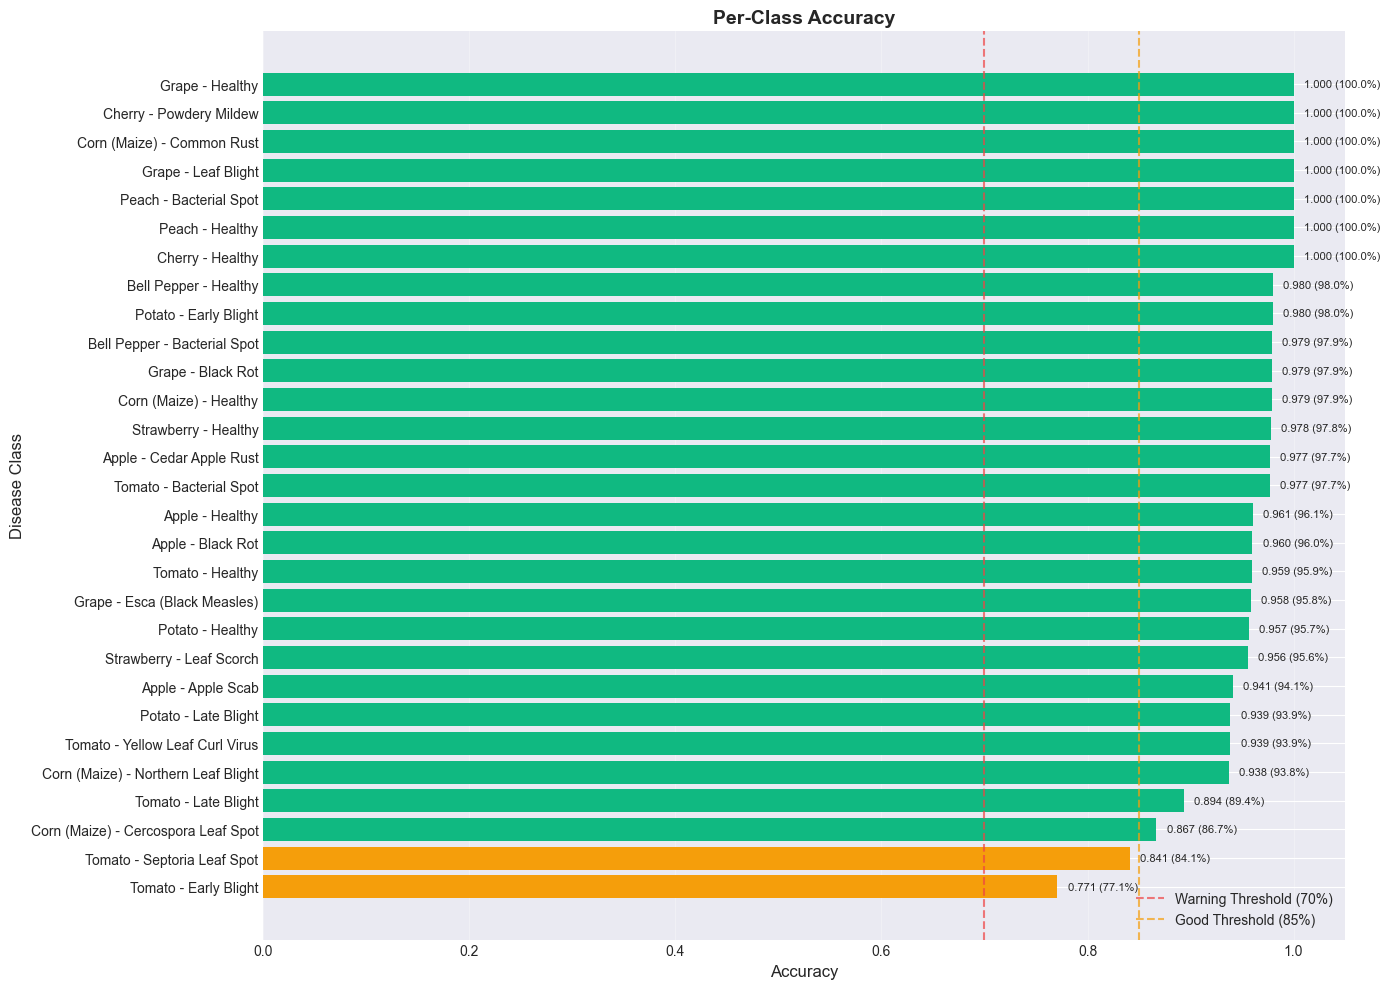

✅ Per-class accuracy chart saved to 'models/per_class_accuracy.png'

📋 Classes Needing Improvement (Accuracy < 70%):
   ✅ All classes have accuracy >= 70%!


In [18]:
# Cell 11: Plot per-class accuracy bar chart
# Create display names
display_names_full = [name.split('___')[-1].replace('_', ' ') if '___' in name else name for name in class_names]

# Sort by accuracy
sorted_acc_indices = np.argsort(per_class_accuracy)
sorted_acc = per_class_accuracy[sorted_acc_indices]
sorted_names = [display_names_full[i] for i in sorted_acc_indices]

# Color based on accuracy
colors_acc = ['#EF4444' if acc < 0.7 else '#F59E0B' if acc < 0.85 else '#10B981' for acc in sorted_acc]

plt.figure(figsize=(14, 10))
bars = plt.barh(sorted_names, sorted_acc, color=colors_acc)

# Add value labels
for bar, acc in zip(bars, sorted_acc):
    plt.text(acc + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{acc:.3f} ({acc*100:.1f}%)', 
             ha='left', va='center', fontsize=8)

# Add threshold lines
plt.axvline(x=0.7, color='#EF4444', linestyle='--', alpha=0.7, label='Warning Threshold (70%)')
plt.axvline(x=0.85, color='#F59E0B', linestyle='--', alpha=0.7, label='Good Threshold (85%)')

plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('Disease Class', fontsize=12)
plt.title('Per-Class Accuracy', fontsize=14, fontweight='bold')
plt.xlim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('models/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Per-class accuracy chart saved to 'models/per_class_accuracy.png'")

# Print classes needing improvement
print("\n📋 Classes Needing Improvement (Accuracy < 70%):")
improvement_needed = [(display_names_full[i], per_class_accuracy[i]) for i in range(num_classes) if per_class_accuracy[i] < 0.7]
if improvement_needed:
    for name, acc in sorted(improvement_needed, key=lambda x: x[1]):
        print(f"   • {name[:40]}: {acc:.4f} ({acc*100:.1f}%)")
else:
    print("   ✅ All classes have accuracy >= 70%!")

Cell 12: Evaluation Summary Report

In [19]:
# Cell 12: Generate comprehensive evaluation summary
print("="*60)
print("📊 MODEL EVALUATION SUMMARY REPORT")
print("="*60)

print(f"\n📁 Evaluation Information:")
print(f"   Evaluation Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"   Test Samples: {len(true_classes)}")
print(f"   Number of Classes: {num_classes}")
print(f"   Model Path: {MODEL_PATH}")

print(f"\n📈 Overall Performance:")
print(f"   Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Precision (weighted): {precision:.4f}")
print(f"   Recall (weighted): {recall:.4f}")
print(f"   F1-Score (weighted): {f1:.4f}")
print(f"   Macro Precision: {report['macro avg']['precision']:.4f}")
print(f"   Macro Recall: {report['macro avg']['recall']:.4f}")
print(f"   Macro F1-Score: {report['macro avg']['f1-score']:.4f}")
print(f"   Average AUC: {np.mean(list(roc_auc.values())):.4f}")

print(f"\n🏆 Best Performing Classes (Top 5 by F1):")
for i, (class_name, f1_score_class) in enumerate(sorted_classes[:5]):
    display_name = class_name.split('___')[-1].replace('_', ' ') if '___' in class_name else class_name
    acc = per_class_accuracy[class_names.index(class_name)]
    print(f"   {i+1}. {display_name[:40]}: F1={f1_score_class:.4f}, Acc={acc:.4f}")

print(f"\n⚠️ Worst Performing Classes (Bottom 5 by F1):")
for i, (class_name, f1_score_class) in enumerate(sorted_classes[-5:][::-1]):
    display_name = class_name.split('___')[-1].replace('_', ' ') if '___' in class_name else class_name
    acc = per_class_accuracy[class_names.index(class_name)]
    print(f"   {i+1}. {display_name[:40]}: F1={f1_score_class:.4f}, Acc={acc:.4f}")

print(f"\n📊 Misclassification Summary:")
print(f"   Total Misclassified: {len(misclassified_indices)}/{len(true_classes)} ({len(misclassified_indices)/len(true_classes)*100:.2f}%)")

print(f"\n✅ Recommendations:")
if accuracy > 0.95:
    print("   - Model performance is excellent! Ready for deployment.")
elif accuracy > 0.90:
    print("   - Model performance is good.")
    print("   - Consider collecting more data for lower-performing classes")
    print("   - Apply additional augmentation for problematic classes")
else:
    print("   - Model needs improvement.")
    print("   - Increase training epochs or collect more data")
    print("   - Try a different base model (EfficientNet, ResNet)")
    print("   - Apply more aggressive augmentation for underrepresented classes")

📊 MODEL EVALUATION SUMMARY REPORT

📁 Evaluation Information:
   Evaluation Date: 2026-06-13 17:57:45
   Test Samples: 1358
   Number of Classes: 29
   Model Path: models/plant_disease_model.h5

📈 Overall Performance:
   Accuracy: 0.9551 (95.51%)
   Precision (weighted): 1.0000
   Recall (weighted): 0.9388
   F1-Score (weighted): 0.9583
   Macro Precision: 0.9560
   Macro Recall: 0.9554
   Macro F1-Score: 0.9548
   Average AUC: 0.9995

🏆 Best Performing Classes (Top 5 by F1):
   1. Cherry - Powdery Mildew: F1=1.0000, Acc=1.0000
   2. Corn (Maize) - Common Rust: F1=1.0000, Acc=1.0000
   3. Peach - Bacterial Spot: F1=1.0000, Acc=1.0000
   4. Peach - Healthy: F1=1.0000, Acc=1.0000
   5. Corn (Maize) - Healthy: F1=0.9892, Acc=0.9787

⚠️ Worst Performing Classes (Bottom 5 by F1):
   1. Tomato - Septoria Leaf Spot: F1=0.8409, Acc=0.8409
   2. Tomato - Early Blight: F1=0.8506, Acc=0.7708
   3. Tomato - Late Blight: F1=0.8842, Acc=0.8936
   4. Corn (Maize) - Cercospora Leaf Spot: F1=0.8864, Acc

Cell 13: Save Evaluation Results

In [20]:
# Cell 13: Save all evaluation results
evaluation_results = {
    'evaluation_date': datetime.now().isoformat(),
    'test_samples': len(true_classes),
    'num_classes': num_classes,
    'model_path': MODEL_PATH,
    'accuracy': float(accuracy),
    'precision_weighted': float(precision),
    'recall_weighted': float(recall),
    'f1_weighted': float(f1),
    'macro_precision': float(report['macro avg']['precision']),
    'macro_recall': float(report['macro avg']['recall']),
    'macro_f1': float(report['macro avg']['f1-score']),
    'avg_auc': float(np.mean(list(roc_auc.values()))),
    'per_class_metrics': {
        class_names[i]: {
            'precision': float(per_class_precision[class_names[i]]),
            'recall': float(per_class_recall[class_names[i]]),
            'f1_score': float(per_class_f1[class_names[i]]),
            'accuracy': float(per_class_accuracy[i]),
            'support': int(cm[i].sum())
        } for i in range(num_classes)
    },
    'misclassified_count': len(misclassified_indices),
    'error_rate': len(misclassified_indices)/len(true_classes)*100,
    'confusion_matrix': cm.tolist(),
    'class_names': class_names
}

# Save to JSON
with open('models/evaluation_results.json', 'w') as f:
    json.dump(evaluation_results, f, indent=2)
print("✅ Evaluation results saved to 'models/evaluation_results.json'")

print("\n" + "="*60)
print("✅ MODEL EVALUATION COMPLETED!")
print("="*60)
print("\n📁 Output files:")
print("   - classification_report.csv")
print("   - confusion_matrix.png")
print("   - roc_curves.png")
print("   - confidence_analysis.png")
print("   - per_class_accuracy.png")
print("   - evaluation_results.json")

✅ Evaluation results saved to 'models/evaluation_results.json'

✅ MODEL EVALUATION COMPLETED!

📁 Output files:
   - classification_report.csv
   - confusion_matrix.png
   - roc_curves.png
   - confidence_analysis.png
   - per_class_accuracy.png
   - evaluation_results.json


Cell 14: Quick Test on Custom Images (Optional)

In [26]:
# Cell 14: Quick test function for custom images
def predict_custom_image(image_path, model, class_names, img_size=(224, 224)):
    """
    Predict disease from a custom image
    """
    from tensorflow.keras.preprocessing.image import load_img, img_to_array
    
    if not os.path.exists(image_path):
        print(f"❌ Image not found: {image_path}")
        return None
    
    # Load and preprocess image
    img = load_img(image_path, target_size=img_size)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    
    # Predict
    predictions = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class] * 100
    
    # Get top 5 predictions
    top_5_idx = np.argsort(predictions[0])[-5:][::-1]
    top_5 = [(class_names[i], predictions[0][i]*100) for i in top_5_idx]
    
    # Display results
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Original image
    axes[0].imshow(img)
    axes[0].set_title(f"Input Image", fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Prediction bar chart
    classes_display = [c[:30] for c, _ in top_5]
    confidences = [c for _, c in top_5]
    colors_bar = ['#4F46E5' if i == 0 else '#94A3B8' for i in range(len(classes_display))]
    axes[1].barh(classes_display, confidences, color=colors_bar)
    axes[1].set_xlabel('Confidence (%)', fontsize=11)
    axes[1].set_title('Top 5 Predictions', fontsize=12, fontweight='bold')
    
    predicted_name = class_names[predicted_class].split('___')[-1].replace('_', ' ') if '___' in class_names[predicted_class] else class_names[predicted_class]
    plt.suptitle(f"Prediction: {predicted_name} ({confidence:.2f}%)", 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return predicted_name, confidence, top_5

# Example usage (uncomment to test):
# test_image = "path/to/your/test/image.jpg"
# if os.path.exists(test_image):
#     predicted, confidence, top_5 = predict_custom_image(test_image, model, class_names)
#     print(f"\n✅ Prediction: {predicted} ({confidence:.2f}%)")

print("\n💡 To test a custom image, use:")
print("   predict_custom_image('path/to/your/image.jpg', model, class_names)")


💡 To test a custom image, use:
   predict_custom_image('path/to/your/image.jpg', model, class_names)
